# Tesla Stock Price Time Series Analysis

## Introduction
This project analyses Tesla stock prices from 1 January 2015 to 1 January 2026 using time series analysis techniques. The aim is to explore historical behaviour in Tesla's closing stock price, test for stationarity, apply forecasting models and evaluate their performance.

The main variable of interest is the closing price as it reflects the final value of Tesla stock at the end of each trading day.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [19]:
import yfinance as yf

data = yf.download("TSLA", start="2015-01-01", end="2026-01-01")

data.to_csv(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\data\tesla_stock_data.csv")


[*********************100%***********************]  1 of 1 completed


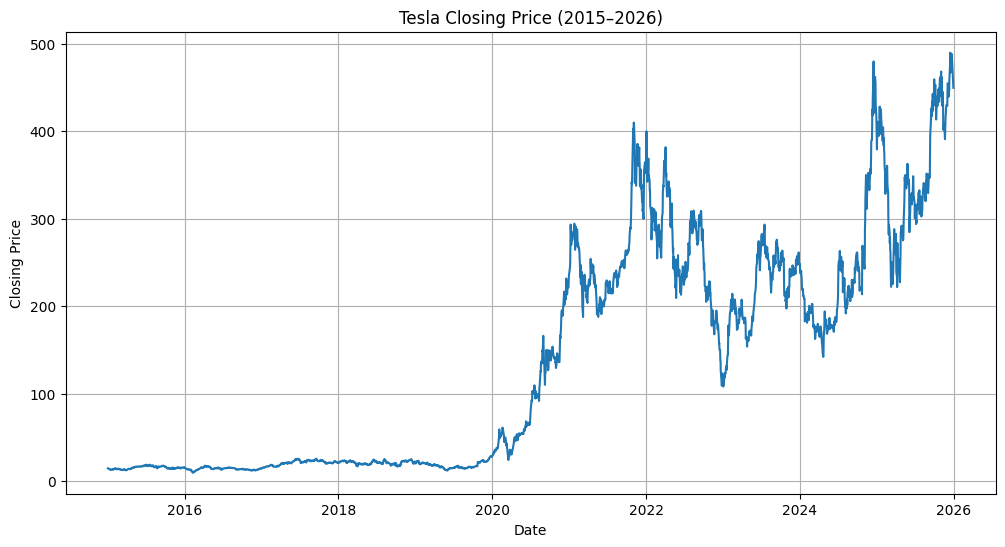

In [22]:
# Flatten columns if needed
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Ensure proper datetime index
data.index = pd.to_datetime(data.index)

# Plot
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(data.index, data["Close"])

ax.set_title("Tesla Closing Price (2015–2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price")

# Fix x-axis formatting
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(True)
plt.show()

## Line Plot Interpretation

The Tesla closing price shows a strong upward trend over the period from 2015 to 2026 indicating long-term growth in the stock value. There are noticeable periods of high volatility particularly after 2020, where the price fluctuates significantly. This suggests that the time series is non-stationary as both the mean and variance change over time.